In [1]:
from google.colab import files
uploaded = files.upload()

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured")

!rm -f /content/*.zip
!kaggle datasets download -d shoybhasan/camus-human-heart-data -p /content --force

!rm -rf /content/camus_data
!mkdir -p /content/camus_data
!unzip -q /content/camus-human-heart-data.zip -d /content/camus_data

!rm -rf /content/camus_full
!mkdir -p /content/camus_full
!unzip -q /content/camus_data/download -d /content/camus_full

import os

print(os.listdir("/content/camus_full")[:10])

root_dir = "/content/camus_full/database_nifti"

print("Using dataset root:", root_dir)
print("Patient folders:", len(os.listdir(root_dir)))
print(os.listdir(root_dir)[:5])

Saving kaggle.json to kaggle.json
Kaggle API configured
Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
100% 3.50G/3.50G [04:12<00:00, 14.9MB/s]

['database_nifti']
Using dataset root: /content/camus_full/database_nifti
Patient folders: 500
['patient0464', 'patient0279', 'patient0139', 'patient0490', 'patient0005']


In [2]:
# =========================
# DATASET ROOT
# =========================
POSSIBLE_ROOTS = [
    "/content/camus_full/database_nifti",
    "/mnt/data/camus_full/database_nifti",
]

root_dir = None
for p in POSSIBLE_ROOTS:
    if os.path.exists(p):
        root_dir = p
        break

if root_dir is None:
    raise FileNotFoundError("CAMUS dataset root not found. Update POSSIBLE_ROOTS or set root_dir manually.")

print("Using dataset root:", root_dir)
print("Number of patient folders:", len(os.listdir(root_dir)))

Using dataset root: /content/camus_full/database_nifti
Number of patient folders: 500


In [3]:
# =========================
# CAMUS DATASET SUMMARY
# =========================

import os

patients = sorted([
    p for p in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, p))
])

num_patients = len(patients)

total_images = 0
total_masks = 0

for patient in patients:
    p_dir = os.path.join(root_dir, patient)
    files = os.listdir(p_dir)

    images = [f for f in files if f.endswith(".nii.gz") and not f.endswith("_gt.nii.gz")]
    masks  = [f for f in files if f.endswith("_gt.nii.gz")]

    total_images += len(images)
    total_masks += len(masks)

print("=========== CAMUS DATASET SUMMARY ===========")
print("Total patients:", num_patients)
print("Total image volumes:", total_images)
print("Total mask volumes:", total_masks)
print("=============================================")

print("\nExample patient folder:", patients[0])
print("Files inside example patient folder:")
print(os.listdir(os.path.join(root_dir, patients[0])))

=========== CAMUS DATASET SUMMARY ===========
Total patients: 500
Total image volumes: 3000
Total mask volumes: 3000

Example patient folder: patient0001
Files inside example patient folder:
['patient0001_2CH_half_sequence_gt.nii.gz', 'patient0001_4CH_ED.nii.gz', 'patient0001_2CH_half_sequence.nii.gz', 'patient0001_2CH_ES_gt.nii.gz', 'MANDATORY_CITATION.md', 'patient0001_4CH_ED_gt.nii.gz', 'patient0001_4CH_ES_gt.nii.gz', 'Info_2CH.cfg', 'patient0001_2CH_ES.nii.gz', 'patient0001_4CH_ES.nii.gz', 'patient0001_4CH_half_sequence_gt.nii.gz', 'Info_4CH.cfg', 'patient0001_2CH_ED_gt.nii.gz', 'patient0001_4CH_half_sequence.nii.gz', 'patient0001_2CH_ED.nii.gz']


In [4]:
# =========================
# IMPORTS
# =========================
import os
import gc
import cv2
import time
import copy
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

!pip install -q segmentation-models-pytorch
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.0 MB/s eta 0:00:00


In [5]:
# =========================
# SEED / DEVICE / SETTINGS
# =========================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Final benchmark recommendation enabled
IMAGE_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 20
NUM_CLASSES = 4

NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
WEIGHT_DECAY = 1e-4
COMPUTE_HD95 = True
COMPUTE_CLINICAL = True
APPLY_POSTPROCESS = True

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"IMAGE_SIZE={IMAGE_SIZE}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}")
print(f"COMPUTE_CLINICAL={COMPUTE_CLINICAL}, APPLY_POSTPROCESS={APPLY_POSTPROCESS}")

Device: cuda
IMAGE_SIZE=512, BATCH_SIZE=2, EPOCHS=20
COMPUTE_CLINICAL=True, APPLY_POSTPROCESS=True


In [6]:
# =========================
# TRANSFORMS
# =========================
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [7]:
# =========================
# PATIENT-LEVEL SPLIT
# train / val / test
# =========================
all_patients = sorted([
    p for p in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, p))
])

rng = np.random.RandomState(SEED)
rng.shuffle(all_patients)

n_total = len(all_patients)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

train_patients = all_patients[:n_train]
val_patients   = all_patients[n_train:n_train + n_val]
test_patients  = all_patients[n_train + n_val:]

print("Train patients:", len(train_patients))
print("Val patients:", len(val_patients))
print("Test patients:", len(test_patients))
print("Total patients:", len(train_patients) + len(val_patients) + len(test_patients))

Train patients: 350
Val patients: 75
Test patients: 75
Total patients: 500


In [8]:
def collect_pairs(patient_list, root_dir):
    pairs = []

    for patient in patient_list:
        patient_dir = os.path.join(root_dir, patient)
        files_here = os.listdir(patient_dir)

        for f in files_here:
            if f.endswith(".nii.gz") and not f.endswith("_gt.nii.gz"):
                if ("_ED.nii.gz" in f) or ("_ES.nii.gz" in f):
                    img_path = os.path.join(patient_dir, f)
                    mask_path = os.path.join(patient_dir, f.replace(".nii.gz", "_gt.nii.gz"))

                    if os.path.exists(mask_path):
                        pairs.append((img_path, mask_path))

    return pairs

In [9]:
# =========================
# DATASET
# =========================
class CamusNiftiDataset(Dataset):
    def __init__(self, pairs, transform=None, size=256):
        self.pairs = pairs
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = np.asanyarray(nib.load(img_path).dataobj).astype(np.float32)
        mask = np.asanyarray(nib.load(mask_path).dataobj).astype(np.int64)

        if img.ndim == 3:
            img = img[:, :, 0]
        if mask.ndim == 3:
            mask = mask[:, :, 0]

        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"].float()
            mask = aug["mask"].long()
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask

In [10]:
train_pairs = collect_pairs(train_patients, root_dir)
val_pairs   = collect_pairs(val_patients, root_dir)
test_pairs  = collect_pairs(test_patients, root_dir)

print("Train samples:", len(train_pairs))
print("Val samples:", len(val_pairs))
print("Test samples:", len(test_pairs))

Train samples: 1400
Val samples: 300
Test samples: 300


In [11]:
train_ds = CamusNiftiDataset(train_pairs, transform=train_transform, size=IMAGE_SIZE)
val_ds   = CamusNiftiDataset(val_pairs, transform=val_transform, size=IMAGE_SIZE)
test_ds  = CamusNiftiDataset(test_pairs, transform=val_transform, size=IMAGE_SIZE)

print("Train dataset:", len(train_ds))
print("Val dataset:", len(val_ds))
print("Test dataset:", len(test_ds))

Train dataset: 1400
Val dataset: 300
Test dataset: 300


In [12]:
img, mask = train_ds[0]

print(img.shape)
print(mask.shape)
print(mask.dtype)
print(torch.unique(mask))

torch.Size([1, 512, 512])
torch.Size([512, 512])
torch.int64
tensor([0, 1, 2, 3])


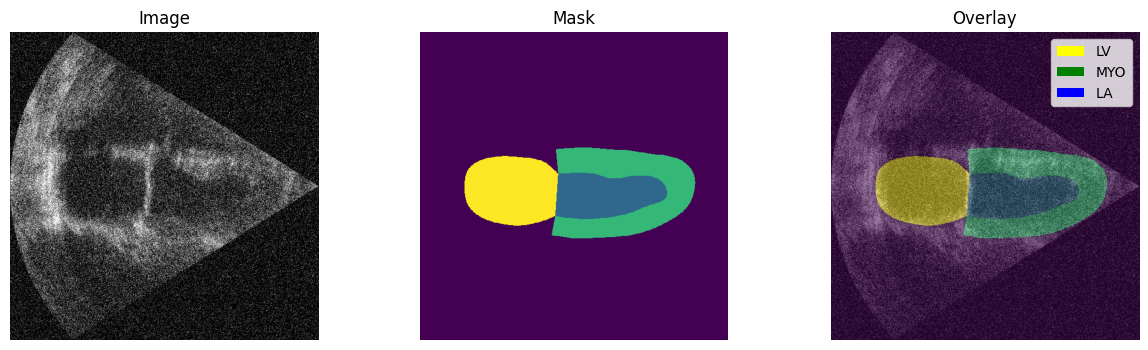

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

img, mask = train_ds[0]

img_np = img.squeeze().cpu().numpy()
mask_np = mask.cpu().numpy()

colors = [
    (0,0,0,0),        # BG transparent
    (1,0,0,0.6),      # LV yellow
    (0,1,0,0.6),      # MYO green
    (0,0,1,0.6)       # LA blue
]

legend_elements = [
    Patch(facecolor='yellow', label='LV'),
    Patch(facecolor='green', label='MYO'),
    Patch(facecolor='blue', label='LA')
]

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img_np, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask_np)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img_np, cmap="gray")
plt.imshow(mask_np, alpha=0.5)
plt.legend(handles=legend_elements, loc="upper right")
plt.axis("off")

plt.show()

In [14]:
# =========================
# SAMPLERS
# WEIGHTED + BALANCED + IMPROVED
# =========================
def load_mask_2d(mask_path):
    mask = np.asanyarray(nib.load(mask_path).dataobj).astype(np.int64)
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    return mask

def infer_view_phase_from_path(img_path):
    fname = os.path.basename(img_path).upper()
    view = "UNK"
    phase = "UNK"

    if "2CH" in fname:
        view = "2CH"
    elif "4CH" in fname:
        view = "4CH"

    if "_ED" in fname:
        phase = "ED"
    elif "_ES" in fname:
        phase = "ES"

    return view, phase

MASK_STATS_CACHE = {}

def get_mask_stats(mask_path):
    if mask_path not in MASK_STATS_CACHE:
        mask = load_mask_2d(mask_path)
        total = float(mask.size)
        counts = {cls: int((mask == cls).sum()) for cls in [0, 1, 2, 3]}
        fracs = {cls: counts[cls] / max(total, 1.0) for cls in [0, 1, 2, 3]}
        MASK_STATS_CACHE[mask_path] = {
            "counts": counts,
            "fracs": fracs,
            "present_classes": [cls for cls in [1, 2, 3] if counts[cls] > 0]
        }
    return MASK_STATS_CACHE[mask_path]

def compute_weighted_sampler_weights(dataset):
    weights = []
    for img_path, mask_path in dataset.pairs:
        classes_present = get_mask_stats(mask_path)["present_classes"]

        w = 1.0
        if 3 in classes_present:   # LA
            w += 2.0
        if 2 in classes_present:   # MYO
            w += 1.5
        if 1 in classes_present:   # LV
            w += 1.0

        weights.append(w)

    return torch.DoubleTensor(weights)

def compute_balanced_sampler_weights(dataset):
    weights = []
    for img_path, mask_path in dataset.pairs:
        classes_present = get_mask_stats(mask_path)["present_classes"]

        if 3 in classes_present:
            w = 4.0
        elif 2 in classes_present:
            w = 3.0
        elif 1 in classes_present:
            w = 2.0
        else:
            w = 1.0

        weights.append(w)

    return torch.DoubleTensor(weights)

def compute_improved_sampler_weights(dataset):
    # area-rarity + view/phase rarity
    records = []
    for img_path, mask_path in dataset.pairs:
        stats = get_mask_stats(mask_path)
        view, phase = infer_view_phase_from_path(img_path)
        records.append({
            "img_path": img_path,
            "mask_path": mask_path,
            "view": view,
            "phase": phase,
            "fracs": stats["fracs"],
            "present_classes": stats["present_classes"]
        })

    view_counts = Counter([r["view"] for r in records])
    phase_counts = Counter([r["phase"] for r in records])

    weights = []
    for r in records:
        w = 1.0

        # reward rare/small structures rather than mere presence
        la_ratio = r["fracs"][3]
        myo_ratio = r["fracs"][2]
        lv_ratio = r["fracs"][1]

        w += 2.0 * (1.0 - min(la_ratio / 0.08, 1.0))
        w += 1.5 * (1.0 - min(myo_ratio / 0.12, 1.0))
        w += 0.8 * (1.0 - min(lv_ratio / 0.20, 1.0))

        # reward rarer view / phase
        w += 0.4 * (1.0 / max(view_counts[r["view"]], 1)) * len(records)
        w += 0.4 * (1.0 / max(phase_counts[r["phase"]], 1)) * len(records)

        weights.append(w)

    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / np.mean(weights)
    return torch.DoubleTensor(weights)

def make_train_loader(train_ds, sampler_choice):
    if sampler_choice == "weighted":
        sample_weights = compute_weighted_sampler_weights(train_ds)
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        shuffle = False
    elif sampler_choice == "balanced":
        sample_weights = compute_balanced_sampler_weights(train_ds)
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        shuffle = False
    elif sampler_choice == "improved":
        sample_weights = compute_improved_sampler_weights(train_ds)
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        shuffle = False
    elif sampler_choice == "uniform":
        sampler = None
        shuffle = True
    else:
        raise ValueError("sampler_choice must be 'weighted', 'balanced', 'improved', or 'uniform'")

    return DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        worker_init_fn=seed_worker,
        generator=g,
    )

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
)

SAMPLER_CHOICE = "improved"
train_loader = make_train_loader(train_ds, SAMPLER_CHOICE)

print("Training sampler:", SAMPLER_CHOICE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training sampler: improved
Train batches: 700
Val batches: 150
Test batches: 150


In [15]:
print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))
print("Test samples:", len(test_ds))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Batch size:", BATCH_SIZE)

Train samples: 1400
Val samples: 300
Test samples: 300
Train batches: 700
Val batches: 150
Test batches: 150
Batch size: 2


In [16]:
# =========================
# EVAL LOADER CHECK
# =========================
print("Validation loader ready:", len(val_loader))
print("Test loader ready:", len(test_loader))

Validation loader ready: 150
Test loader ready: 150


In [17]:
# =========================
# PIXEL SHARE CHECK
# =========================
def compute_pixel_share(loader, max_batches=None):
    cnt = Counter()

    for b, (_, y) in enumerate(loader):
        y = y.numpy()
        cnt[0] += (y == 0).sum()
        cnt[1] += (y == 1).sum()
        cnt[2] += (y == 2).sum()
        cnt[3] += (y == 3).sum()

        if max_batches is not None and (b + 1) >= max_batches:
            break

    total = sum(cnt.values())
    return {cls: cnt[cls] / total for cls in [0, 1, 2, 3]}

shares = []
for sampler_name in ["uniform", "weighted", "balanced", "improved"]:
    loader = make_train_loader(train_ds, sampler_name)
    s = compute_pixel_share(loader, max_batches=10)
    shares.append({
        "sampler": sampler_name,
        "BG": s[0],
        "LV": s[1],
        "MYO": s[2],
        "LA": s[3],
    })

pd.DataFrame(shares)

,sampler,BG,LV,MYO,LA
0,uniform,0.788105,0.078685,0.082331,0.050879
1,weighted,0.757455,0.085820,0.101553,0.055172
2,balanced,0.758341,0.091590,0.096387,0.053682
3,improved,0.754714,0.103500,0.097714,0.044071


In [18]:
# =========================
# MODELS
# =========================
def model_unet():     # Paper 1 + Paper 5
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

def model_deeplab():  # Paper 2
    return smp.DeepLabV3(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

def model_resunet():  # Paper 4
    return smp.Unet(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

def model_attention_unet():
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES,
        decoder_attention_type="scse",
    ).to(device)

def model_unetpp():
    return smp.UnetPlusPlus(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES,
    ).to(device)

print("Added active models: Attention U-Net and U-Net++")

Added active models: Attention U-Net and U-Net++


In [19]:
# =========================
# LOSSES
# NON-FOCAL = WEIGHTED CE
# FOCAL + DICE = FOR ALL FOCAL RUNS
# =========================
def soft_dice_loss(logits, targets, num_classes=NUM_CLASSES, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_oh = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()

    dims = (0, 2, 3)
    intersection = torch.sum(probs * targets_oh, dims)
    union = torch.sum(probs + targets_oh, dims)
    dice = (2 * intersection + eps) / (union + eps)

    # ignore background
    return 1 - dice[1:].mean()

class CEPlusDice(nn.Module):
    def __init__(self, ce_weight=0.5, ce_loss=None):
        super().__init__()
        self.ce_weight = ce_weight
        self.ce = ce_loss if ce_loss is not None else nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + (1 - self.ce_weight) * soft_dice_loss(logits, targets)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_map = self.alpha[targets]
            focal = alpha_map * focal

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        return focal

class FocalPlusDice(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, focal_weight=0.5):
        super().__init__()
        self.focal = FocalLoss(alpha=alpha, gamma=gamma, reduction="mean")
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        return self.focal_weight * self.focal(logits, targets) + (1 - self.focal_weight) * soft_dice_loss(logits, targets)

class_weights = torch.tensor([0.2, 1.0, 1.0, 1.3], device=device)

ce_weighted = nn.CrossEntropyLoss(weight=class_weights)
ce_plus_dice = CEPlusDice(ce_weight=0.5, ce_loss=ce_weighted)

focal_plus_dice = FocalPlusDice(
    alpha=class_weights,
    gamma=2.0,
    focal_weight=0.5
)

print("Losses ready")
print("Class weights:", class_weights.detach().cpu().numpy())

Losses ready
Class weights: [0.2 1.  1.  1.3]


In [20]:
# =========================
# METRICS + POSTPROCESS + CLINICAL HELPERS
# =========================
def largest_component(binary_mask):
    binary_mask = binary_mask.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    if num_labels <= 1:
        return binary_mask
    largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_idx).astype(np.uint8)

def fill_holes(binary_mask):
    binary_mask = binary_mask.astype(np.uint8)
    h, w = binary_mask.shape
    flood = binary_mask.copy()
    mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, mask, (0, 0), 1)
    flood_inv = 1 - flood
    return np.clip(binary_mask + flood_inv, 0, 1)

def postprocess_multiclass_mask(pred_mask):
    out = np.zeros_like(pred_mask, dtype=np.uint8)
    occupied = np.zeros_like(pred_mask, dtype=bool)

    for cls in [1, 2, 3]:
        cls_mask = (pred_mask == cls).astype(np.uint8)
        if cls_mask.sum() == 0:
            continue
        cls_mask = largest_component(cls_mask)
        cls_mask = fill_holes(cls_mask)
        cls_mask = np.logical_and(cls_mask > 0, ~occupied)
        out[cls_mask] = cls
        occupied |= cls_mask

    return out.astype(np.uint8)

def dice_per_class(preds, targets, cls, eps=1e-6):
    pred_c = (preds == cls).astype(np.uint8)
    targ_c = (targets == cls).astype(np.uint8)

    inter = (pred_c * targ_c).sum()
    denom = pred_c.sum() + targ_c.sum()

    if denom == 0:
        return np.nan

    return (2.0 * inter + eps) / (denom + eps)

def hd95_per_class(preds, targets, cls):
    if not HD95_AVAILABLE or (not COMPUTE_HD95):
        return np.nan

    pred_bin = (preds == cls).astype(np.uint8)
    true_bin = (targets == cls).astype(np.uint8)

    if pred_bin.sum() == 0 or true_bin.sum() == 0:
        return np.nan

    try:
        return medpy_hd95(pred_bin, true_bin)
    except:
        return np.nan

def mean_ignore_nan(values):
    values = [v for v in values if not np.isnan(v)]
    return float(np.mean(values)) if len(values) else np.nan

def estimate_lv_area_from_mask(mask_bin, spacing_xy=(1.0, 1.0)):
    sx, sy = spacing_xy
    return float(mask_bin.sum()) * sx * sy

def estimate_lv_length_from_mask(mask_bin, spacing_xy=(1.0, 1.0)):
    ys, xs = np.where(mask_bin > 0)
    if len(xs) < 5:
        return np.nan
    sx, sy = spacing_xy
    pts = np.stack([xs * sx, ys * sy], axis=1).astype(np.float32)
    pts_centered = pts - pts.mean(axis=0, keepdims=True)
    cov = np.cov(pts_centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major_vec = eigvecs[:, np.argmax(eigvals)]
    proj = pts_centered @ major_vec
    return float(proj.max() - proj.min())

def estimate_biplane_volume_ml(mask_2ch, mask_4ch, spacing_2ch=(1.0, 1.0), spacing_4ch=(1.0, 1.0)):
    A2 = estimate_lv_area_from_mask(mask_2ch, spacing_2ch)
    A4 = estimate_lv_area_from_mask(mask_4ch, spacing_4ch)
    L2 = estimate_lv_length_from_mask(mask_2ch, spacing_2ch)
    L4 = estimate_lv_length_from_mask(mask_4ch, spacing_4ch)

    if np.isnan(L2) or np.isnan(L4) or max(L2, L4) <= 0:
        return np.nan

    L = max(L2, L4)
    vol_mm3 = 0.85 * A2 * A4 / max(L, 1e-6)
    return vol_mm3 / 1000.0

def get_original_spacing_xy(img_path):
    nii = nib.load(img_path)
    zooms = nii.header.get_zooms()
    if len(zooms) >= 2:
        sx, sy = float(zooms[0]), float(zooms[1])
    else:
        sx, sy = 1.0, 1.0
    arr = np.asanyarray(nii.dataobj)
    if arr.ndim == 3:
        h, w = arr[:, :, 0].shape
    else:
        h, w = arr.shape
    # resized to IMAGE_SIZE x IMAGE_SIZE
    return sx * (w / IMAGE_SIZE), sy * (h / IMAGE_SIZE)

def evaluate_fast(model, loader, dataset_pairs=None, apply_postprocess=APPLY_POSTPROCESS):
    model.eval()

    d1, d2, d3 = [], [], []
    hd_lv, hd_myo, hd_la = [], [], []

    clinical_pred = {}
    clinical_true = {}

    with torch.no_grad():
        pair_idx = 0
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_np = y.numpy()

            for i in range(len(preds)):
                pred_i = preds[i]
                true_i = y_np[i]

                if apply_postprocess:
                    pred_i = postprocess_multiclass_mask(pred_i)

                d_lv  = dice_per_class(pred_i, true_i, 1)
                d_myo = dice_per_class(pred_i, true_i, 2)
                d_la  = dice_per_class(pred_i, true_i, 3)

                if not np.isnan(d_lv):
                    d1.append(d_lv)
                if not np.isnan(d_myo):
                    d2.append(d_myo)
                if not np.isnan(d_la):
                    d3.append(d_la)

                hd_lv.append(hd95_per_class(pred_i, true_i, 1))
                hd_myo.append(hd95_per_class(pred_i, true_i, 2))
                hd_la.append(hd95_per_class(pred_i, true_i, 3))

                # approximate clinical metrics using paired 2CH / 4CH ED / ES
                if COMPUTE_CLINICAL and dataset_pairs is not None and pair_idx < len(dataset_pairs):
                    img_path, mask_path = dataset_pairs[pair_idx]
                    patient = os.path.basename(os.path.dirname(img_path))
                    view, phase = infer_view_phase_from_path(img_path)
                    spacing_xy = get_original_spacing_xy(img_path)

                    key = (patient, phase)
                    clinical_pred.setdefault(key, {})
                    clinical_true.setdefault(key, {})

                    clinical_pred[key][view] = {
                        "mask": (pred_i == 1).astype(np.uint8),
                        "spacing": spacing_xy,
                    }
                    clinical_true[key][view] = {
                        "mask": (true_i == 1).astype(np.uint8),
                        "spacing": spacing_xy,
                    }

                pair_idx += 1

    fg_all = d1 + d2 + d3
    result = {
        "dice_LV":  float(np.mean(d1)) if len(d1) else np.nan,
        "dice_MYO": float(np.mean(d2)) if len(d2) else np.nan,
        "dice_LA":  float(np.mean(d3)) if len(d3) else np.nan,
        "fg_dice_mean": float(np.mean(fg_all)) if len(fg_all) else np.nan,
        "hd95_LV":  mean_ignore_nan(hd_lv),
        "hd95_MYO": mean_ignore_nan(hd_myo),
        "hd95_LA":  mean_ignore_nan(hd_la),
    }

    if COMPUTE_CLINICAL:
        edv_errs, esv_errs, ef_errs = [], [], []
        for patient in sorted({k[0] for k in clinical_true.keys()}):
            pred_ed = clinical_pred.get((patient, "ED"), {})
            pred_es = clinical_pred.get((patient, "ES"), {})
            true_ed = clinical_true.get((patient, "ED"), {})
            true_es = clinical_true.get((patient, "ES"), {})

            if all(v in pred_ed for v in ["2CH", "4CH"]) and all(v in pred_es for v in ["2CH", "4CH"]) and \
               all(v in true_ed for v in ["2CH", "4CH"]) and all(v in true_es for v in ["2CH", "4CH"]):

                pred_edv = estimate_biplane_volume_ml(
                    pred_ed["2CH"]["mask"], pred_ed["4CH"]["mask"],
                    pred_ed["2CH"]["spacing"], pred_ed["4CH"]["spacing"]
                )
                pred_esv = estimate_biplane_volume_ml(
                    pred_es["2CH"]["mask"], pred_es["4CH"]["mask"],
                    pred_es["2CH"]["spacing"], pred_es["4CH"]["spacing"]
                )
                true_edv = estimate_biplane_volume_ml(
                    true_ed["2CH"]["mask"], true_ed["4CH"]["mask"],
                    true_ed["2CH"]["spacing"], true_ed["4CH"]["spacing"]
                )
                true_esv = estimate_biplane_volume_ml(
                    true_es["2CH"]["mask"], true_es["4CH"]["mask"],
                    true_es["2CH"]["spacing"], true_es["4CH"]["spacing"]
                )

                if not any(np.isnan(v) for v in [pred_edv, pred_esv, true_edv, true_esv]) and true_edv > 0 and pred_edv > 0:
                    pred_ef = 100.0 * (pred_edv - pred_esv) / pred_edv
                    true_ef = 100.0 * (true_edv - true_esv) / true_edv

                    edv_errs.append(abs(pred_edv - true_edv))
                    esv_errs.append(abs(pred_esv - true_esv))
                    ef_errs.append(abs(pred_ef - true_ef))

        result["EDV_MAE_ml"] = float(np.mean(edv_errs)) if len(edv_errs) else np.nan
        result["ESV_MAE_ml"] = float(np.mean(esv_errs)) if len(esv_errs) else np.nan
        result["EF_MAE_pct"] = float(np.mean(ef_errs)) if len(ef_errs) else np.nan

    return result

In [21]:
# =========================
# OPTIONAL HD95
# =========================
try:
    !pip install -q medpy
    from medpy.metric.binary import hd95 as medpy_hd95
    HD95_AVAILABLE = True
except:
    HD95_AVAILABLE = False

print("HD95 available:", HD95_AVAILABLE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 51.3 MB/s eta 0:00:00
HD95 available: True


In [22]:
# =========================
# TRAINING
# =========================
train_histories = {}

def train_model_best(model, loss_fn, epochs=10, log_every=10, patience=5, lr=1e-4, run_name="run"):
    global train_loader, val_loader

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=2
    )
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_score = -1
    best_wts = None
    wait = 0
    history = []

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0

        for bi, (x, y) in enumerate(train_loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True).long()

            opt.zero_grad()

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = loss_fn(logits, y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            train_loss_sum += loss.item()

        train_loss = train_loss_sum / max(1, len(train_loader))

        model.eval()
        val_loss_sum = 0.0
        val_dices = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True).long()

                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = loss_fn(logits, y)

                val_loss_sum += loss.item()

                preds = torch.argmax(logits, dim=1).cpu().numpy()
                y_np = y.cpu().numpy()

                batch_fg = []
                for i in range(len(preds)):
                    pred_i = postprocess_multiclass_mask(preds[i]) if APPLY_POSTPROCESS else preds[i]
                    for cls in [1, 2, 3]:
                        d = dice_per_class(pred_i, y_np[i], cls)
                        if not np.isnan(d):
                            batch_fg.append(d)

                if len(batch_fg):
                    val_dices.append(np.mean(batch_fg))

        val_loss = val_loss_sum / max(1, len(val_loader))
        val_score = float(np.mean(val_dices)) if len(val_dices) else 0.0

        scheduler.step(val_score)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_fg_dice": val_score,
            "lr": opt.param_groups[0]["lr"]
        })

        print(f"{run_name} | Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_fg_dice={val_score:.4f}")

        if val_score > best_score:
            best_score = val_score
            best_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered for {run_name}")
                break

    if best_wts is not None:
        model.load_state_dict(best_wts)

    train_histories[run_name] = pd.DataFrame(history)
    return model

In [23]:
# =========================
# RUN ONE
# NOTE:
# - Original legacy runs are preserved
# - Test-set metrics are now the primary reported metrics
# - Validation metrics are also stored for reference
# =========================
results = {}
all_rows = []

def run_one(name, model_fn, loss_fn, sampler_choice):
    global train_loader

    print("\n" + "=" * 70)
    print("Starting:", name)
    print("=" * 70)

    train_loader = make_train_loader(train_ds, sampler_choice)
    print("Sampler:", sampler_choice)
    print("Train batches:", len(train_loader))
    print("Val batches:", len(val_loader))
    print("Test batches:", len(test_loader))

    m = model_fn()

    start_time = time.time()

    m = train_model_best(
        m,
        loss_fn,
        epochs=EPOCHS,
        log_every=10,
        patience=3,
        lr=1e-4,
        run_name=name
    )

    elapsed = time.time() - start_time

    val_res  = evaluate_fast(m, val_loader, dataset_pairs=val_ds.pairs)
    test_res = evaluate_fast(m, test_loader, dataset_pairs=test_ds.pairs)

    row = {"Experiment_Name": name, "Sampler": sampler_choice}
    row.update(test_res)
    row.update({f"val_{k}": v for k, v in val_res.items()})
    row["Time_Sec"] = elapsed

    weight_file = f"best_{name}.pth"
    hist_file = f"history_{name}.csv"

    torch.save(m.state_dict(), weight_file)

    hist_df = train_histories[name].copy()
    hist_df["Experiment_Name"] = name
    hist_df["Sampler"] = sampler_choice
    hist_df.to_csv(hist_file, index=False)

    row["Weight_File"] = weight_file
    row["History_File"] = hist_file
    all_rows.append(row)
    results[name] = row

    print("Finished:", name)
    print("Validation metrics:", val_res)
    print("Test metrics:", test_res)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return m

In [24]:
img, mask = train_ds[0]
print("img dtype:", img.dtype, "shape:", img.shape)
print("mask dtype:", mask.dtype, "shape:", mask.shape)
print("unique mask labels:", torch.unique(mask))

img dtype: torch.float32 shape: torch.Size([1, 512, 512])
mask dtype: torch.int64 shape: torch.Size([512, 512])
unique mask labels: tensor([0, 1, 2, 3])


In [25]:
test_model = run_one("debug_test_improved_sampler", model_unet, ce_plus_dice, "improved")


Starting: debug_test_improved_sampler
Sampler: improved
Train batches: 700
Val batches: 150
Test batches: 150


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

debug_test_improved_sampler | Epoch 1/20 | train_loss=0.4826 | val_loss=1.4229 | val_fg_dice=0.1184
debug_test_improved_sampler | Epoch 2/20 | train_loss=0.2358 | val_loss=0.9581 | val_fg_dice=0.4699
debug_test_improved_sampler | Epoch 3/20 | train_loss=0.2057 | val_loss=0.2227 | val_fg_dice=0.8195
debug_test_improved_sampler | Epoch 4/20 | train_loss=0.1796 | val_loss=0.2071 | val_fg_dice=0.8442
debug_test_improved_sampler | Epoch 5/20 | train_loss=0.1759 | val_loss=0.2420 | val_fg_dice=0.8123
debug_test_improved_sampler | Epoch 6/20 | train_loss=0.1717 | val_loss=0.2761 | val_fg_dice=0.8105
debug_test_improved_sampler | Epoch 7/20 | train_loss=0.1595 | val_loss=0.1650 | val_fg_dice=0.8794
debug_test_improved_sampler | Epoch 8/20 | train_loss=0.1633 | val_loss=0.1813 | val_fg_dice=0.8638
debug_test_improved_sampler | Epoch 9/20 | train_loss=0.1576 | val_loss=0.1585 | val_fg_dice=0.8854
debug_test_improved_sampler | Epoch 10/20 | train_loss=0.1462 | val_loss=0.1601 | val_fg_dice=0.8820

In [26]:
# =========================
# RUN ALL EXPERIMENTS
# Original 20 legacy experiments kept
# active Attention U-Net and U-Net++ experiments
# improved-sampler CE+Dice runs
# =========================

# ---------- WEIGHTED + NON-FOCAL ----------
m1_wn = run_one("Paper1_UNet_weighted_non_focal", model_unet, ce_weighted, "weighted")
m2_wn = run_one("Paper2_DeepLabV3_weighted_non_focal", model_deeplab, ce_weighted, "weighted")
m3_wn = run_one("Paper3_UNet_CE+Dice_weighted_non_focal", model_unet, ce_plus_dice, "weighted")
m4_wn = run_one("Paper4_ResUNet_weighted_non_focal", model_resunet, ce_weighted, "weighted")
m5_wn = run_one("Paper5_UNet_Baseline_weighted_non_focal", model_unet, ce_weighted, "weighted")
m6_wn = run_one("AttentionUNet_weighted_non_focal", model_attention_unet, ce_weighted, "weighted")
m7_wn = run_one("UNetPP_weighted_non_focal", model_unetpp, ce_weighted, "weighted")

# ---------- WEIGHTED + FOCAL + DICE ----------
m1_wf = run_one("Paper1_UNet_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")
m2_wf = run_one("Paper2_DeepLabV3_weighted_focal_dice", model_deeplab, focal_plus_dice, "weighted")
m3_wf = run_one("Paper3_UNet_CE+Dice_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")
m4_wf = run_one("Paper4_ResUNet_weighted_focal_dice", model_resunet, focal_plus_dice, "weighted")
m5_wf = run_one("Paper5_UNet_Baseline_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")
m6_wf = run_one("AttentionUNet_weighted_focal_dice", model_attention_unet, focal_plus_dice, "weighted")
m7_wf = run_one("UNetPP_weighted_focal_dice", model_unetpp, focal_plus_dice, "weighted")

# ---------- BALANCED + NON-FOCAL ----------
m1_bn = run_one("Paper1_UNet_balanced_non_focal", model_unet, ce_weighted, "balanced")
m2_bn = run_one("Paper2_DeepLabV3_balanced_non_focal", model_deeplab, ce_weighted, "balanced")
m3_bn = run_one("Paper3_UNet_CE+Dice_balanced_non_focal", model_unet, ce_plus_dice, "balanced")
m4_bn = run_one("Paper4_ResUNet_balanced_non_focal", model_resunet, ce_weighted, "balanced")
m5_bn = run_one("Paper5_UNet_Baseline_balanced_non_focal", model_unet, ce_weighted, "balanced")
m6_bn = run_one("AttentionUNet_balanced_non_focal", model_attention_unet, ce_weighted, "balanced")
m7_bn = run_one("UNetPP_balanced_non_focal", model_unetpp, ce_weighted, "balanced")

# ---------- BALANCED + FOCAL + DICE ----------
m1_bf = run_one("Paper1_UNet_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")
m2_bf = run_one("Paper2_DeepLabV3_balanced_focal_dice", model_deeplab, focal_plus_dice, "balanced")
m3_bf = run_one("Paper3_UNet_CE+Dice_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")
m4_bf = run_one("Paper4_ResUNet_balanced_focal_dice", model_resunet, focal_plus_dice, "balanced")
m5_bf = run_one("Paper5_UNet_Baseline_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")
m6_bf = run_one("AttentionUNet_balanced_focal_dice", model_attention_unet, focal_plus_dice, "balanced")
m7_bf = run_one("UNetPP_balanced_focal_dice", model_unetpp, focal_plus_dice, "balanced")

# ---------- RECOMMENDED IMPROVED SAMPLER + CE+DICE ----------
r1 = run_one("Recommended_UNet_improved_ce_dice", model_unet, ce_plus_dice, "improved")
r2 = run_one("Recommended_AttentionUNet_improved_ce_dice", model_attention_unet, ce_plus_dice, "improved")
r3 = run_one("Recommended_UNetPP_improved_ce_dice", model_unetpp, ce_plus_dice, "improved")
r4 = run_one("Recommended_DeepLabV3_improved_ce_dice", model_deeplab, ce_plus_dice, "improved")
r5 = run_one("Recommended_ResUNet_improved_ce_dice", model_resunet, ce_plus_dice, "improved")


Starting: Paper1_UNet_weighted_non_focal
Sampler: weighted
Train batches: 700
Val batches: 150
Test batches: 150
Paper1_UNet_weighted_non_focal | Epoch 1/20 | train_loss=0.5190 | val_loss=0.3420 | val_fg_dice=0.7717
Paper1_UNet_weighted_non_focal | Epoch 2/20 | train_loss=0.2530 | val_loss=0.8817 | val_fg_dice=0.5201
Paper1_UNet_weighted_non_focal | Epoch 3/20 | train_loss=0.2054 | val_loss=0.2084 | val_fg_dice=0.8307
Paper1_UNet_weighted_non_focal | Epoch 4/20 | train_loss=0.2015 | val_loss=0.1824 | val_fg_dice=0.8632
Paper1_UNet_weighted_non_focal | Epoch 5/20 | train_loss=0.1781 | val_loss=0.1643 | val_fg_dice=0.8630
Paper1_UNet_weighted_non_focal | Epoch 6/20 | train_loss=0.1676 | val_loss=0.1981 | val_fg_dice=0.8321
Paper1_UNet_weighted_non_focal | Epoch 7/20 | train_loss=0.1608 | val_loss=0.1658 | val_fg_dice=0.8633
Paper1_UNet_weighted_non_focal | Epoch 8/20 | train_loss=0.1460 | val_loss=0.1467 | val_fg_dice=0.8666
Paper1_UNet_weighted_non_focal | Epoch 9/20 | train_loss=0.138

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Paper4_ResUNet_weighted_non_focal | Epoch 1/20 | train_loss=0.4439 | val_loss=0.2449 | val_fg_dice=0.8235
Paper4_ResUNet_weighted_non_focal | Epoch 2/20 | train_loss=0.2491 | val_loss=0.2361 | val_fg_dice=0.8281
Paper4_ResUNet_weighted_non_focal | Epoch 3/20 | train_loss=0.2189 | val_loss=0.2604 | val_fg_dice=0.8199
Paper4_ResUNet_weighted_non_focal | Epoch 4/20 | train_loss=0.1961 | val_loss=0.2080 | val_fg_dice=0.8398
Paper4_ResUNet_weighted_non_focal | Epoch 5/20 | train_loss=0.1860 | val_loss=0.1807 | val_fg_dice=0.8488
Paper4_ResUNet_weighted_non_focal | Epoch 6/20 | train_loss=0.1691 | val_loss=0.1954 | val_fg_dice=0.8557
Paper4_ResUNet_weighted_non_focal | Epoch 7/20 | train_loss=0.1692 | val_loss=0.1731 | val_fg_dice=0.8556
Paper4_ResUNet_weighted_non_focal | Epoch 8/20 | train_loss=0.1640 | val_loss=0.1722 | val_fg_dice=0.8687
Paper4_ResUNet_weighted_non_focal | Epoch 9/20 | train_loss=0.1783 | val_loss=0.1610 | val_fg_dice=0.8690
Paper4_ResUNet_weighted_non_focal | Epoch 10/2

In [27]:
results_df = pd.DataFrame(all_rows)
print("Number of experiments:", len(results_df))
results_df.head()

Number of experiments: 34


,Experiment_Name,Sampler,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,EDV_MAE_ml,...,val_fg_dice_mean,val_hd95_LV,val_hd95_MYO,val_hd95_LA,val_EDV_MAE_ml,val_ESV_MAE_ml,val_EF_MAE_pct,Time_Sec,Weight_File,History_File
0,debug_test_improved_sampler,improved,0.926350,0.854688,0.876509,0.885849,13.154904,15.433832,16.775996,8.311235,...,0.885733,13.288716,15.446510,17.340049,8.515750,5.552576,5.936545,437.410685,best_debug_test_improved_sampler.pth,history_debug_test_improved_sampler.csv
1,Paper1_UNet_weighted_non_focal,weighted,0.932291,0.855179,0.873735,0.887068,12.068452,15.082281,17.917675,7.199464,...,0.887445,11.997478,14.959465,18.642823,7.881278,5.064927,5.379964,723.276096,best_Paper1_UNet_weighted_non_focal.pth,history_Paper1_UNet_weighted_non_focal.csv
2,Paper2_DeepLabV3_weighted_non_focal,weighted,0.922054,0.855483,0.857681,0.878406,13.982073,15.295493,19.712145,11.708749,...,0.881583,12.617820,14.319898,19.898270,11.375723,5.808719,5.621619,553.828789,best_Paper2_DeepLabV3_weighted_non_focal.pth,history_Paper2_DeepLabV3_weighted_non_focal.csv
3,Paper3_UNet_CE+Dice_weighted_non_focal,weighted,0.927066,0.834918,0.885537,0.882507,13.200487,17.208609,16.118475,8.308106,...,0.879742,13.324734,17.367955,18.247654,7.481424,7.253586,6.803305,253.846524,best_Paper3_UNet_CE+Dice_weighted_non_focal.pth,history_Paper3_UNet_CE+Dice_weighted_non_focal...
4,Paper4_ResUNet_weighted_non_focal,weighted,0.922526,0.834847,0.843466,0.866946,14.318003,19.261749,21.794709,8.231262,...,0.869154,13.551526,17.956936,21.670506,7.492294,6.083165,5.685781,651.946446,best_Paper4_ResUNet_weighted_non_focal.pth,history_Paper4_ResUNet_weighted_non_focal.csv


In [28]:
def parse_experiment_name(name):
    parts = name.split("_")

    if "improved" in parts:
        sampler = "improved"
    elif "weighted" in parts:
        sampler = "weighted"
    elif "balanced" in parts:
        sampler = "balanced"
    else:
        sampler = "unknown"

    if "non" in parts and "focal" in parts:
        loss_type = "non_focal"
    elif "focal" in parts and "dice" in parts:
        loss_type = "focal_dice"
    elif "ce" in parts and "dice" in parts:
        loss_type = "ce_dice"
    else:
        loss_type = "unknown"

    if name.startswith("Paper1"):
        model = "Paper1_UNet"
    elif name.startswith("Paper2"):
        model = "Paper2_DeepLabV3"
    elif name.startswith("Paper3"):
        model = "Paper3_UNet_CE+Dice"
    elif name.startswith("Paper4"):
        model = "Paper4_ResUNet"
    elif name.startswith("Paper5"):
        model = "Paper5_UNet_Baseline"
    elif name.startswith("AttentionUNet"):
        model = "AttentionUNet"
    elif name.startswith("UNetPP"):
        model = "UNetPP"
    elif name.startswith("Recommended_UNet"):
        model = "Recommended_UNet"
    elif name.startswith("Recommended_AttentionUNet"):
        model = "Recommended_AttentionUNet"
    elif name.startswith("Recommended_UNetPP"):
        model = "Recommended_UNetPP"
    elif name.startswith("Recommended_DeepLabV3"):
        model = "Recommended_DeepLabV3"
    elif name.startswith("Recommended_ResUNet"):
        model = "Recommended_ResUNet"
    else:
        model = "Unknown"

    return model, sampler, loss_type

parsed = results_df["Experiment_Name"].apply(parse_experiment_name)
results_df["Model"] = parsed.apply(lambda x: x[0])
results_df["Sampler"] = parsed.apply(lambda x: x[1])
results_df["Loss_Type"] = parsed.apply(lambda x: x[2])

results_df.head()

,Experiment_Name,Sampler,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,EDV_MAE_ml,...,val_hd95_MYO,val_hd95_LA,val_EDV_MAE_ml,val_ESV_MAE_ml,val_EF_MAE_pct,Time_Sec,Weight_File,History_File,Model,Loss_Type
0,debug_test_improved_sampler,improved,0.926350,0.854688,0.876509,0.885849,13.154904,15.433832,16.775996,8.311235,...,15.446510,17.340049,8.515750,5.552576,5.936545,437.410685,best_debug_test_improved_sampler.pth,history_debug_test_improved_sampler.csv,Unknown,unknown
1,Paper1_UNet_weighted_non_focal,weighted,0.932291,0.855179,0.873735,0.887068,12.068452,15.082281,17.917675,7.199464,...,14.959465,18.642823,7.881278,5.064927,5.379964,723.276096,best_Paper1_UNet_weighted_non_focal.pth,history_Paper1_UNet_weighted_non_focal.csv,Paper1_UNet,non_focal
2,Paper2_DeepLabV3_weighted_non_focal,weighted,0.922054,0.855483,0.857681,0.878406,13.982073,15.295493,19.712145,11.708749,...,14.319898,19.898270,11.375723,5.808719,5.621619,553.828789,best_Paper2_DeepLabV3_weighted_non_focal.pth,history_Paper2_DeepLabV3_weighted_non_focal.csv,Paper2_DeepLabV3,non_focal
3,Paper3_UNet_CE+Dice_weighted_non_focal,weighted,0.927066,0.834918,0.885537,0.882507,13.200487,17.208609,16.118475,8.308106,...,17.367955,18.247654,7.481424,7.253586,6.803305,253.846524,best_Paper3_UNet_CE+Dice_weighted_non_focal.pth,history_Paper3_UNet_CE+Dice_weighted_non_focal...,Paper3_UNet_CE+Dice,non_focal
4,Paper4_ResUNet_weighted_non_focal,weighted,0.922526,0.834847,0.843466,0.866946,14.318003,19.261749,21.794709,8.231262,...,17.956936,21.670506,7.492294,6.083165,5.685781,651.946446,best_Paper4_ResUNet_weighted_non_focal.pth,history_Paper4_ResUNet_weighted_non_focal.csv,Paper4_ResUNet,non_focal


In [29]:
report_df = results_df[[
    "Model",
    "Sampler",
    "Loss_Type",
    "dice_LV",
    "dice_MYO",
    "dice_LA",
    "fg_dice_mean",
    "hd95_LV",
    "hd95_MYO",
    "hd95_LA",
    "EDV_MAE_ml",
    "ESV_MAE_ml",
    "EF_MAE_pct",
    "val_fg_dice_mean",
    "Time_Sec"
]].sort_values(by="fg_dice_mean", ascending=False)

report_df.head(20)

,Model,Sampler,Loss_Type,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,EDV_MAE_ml,ESV_MAE_ml,EF_MAE_pct,val_fg_dice_mean,Time_Sec
13,AttentionUNet,weighted,focal_dice,0.931915,0.868438,0.896820,0.899058,12.399421,13.421245,14.901704,8.370638,4.194926,3.790712,0.897970,862.645389
12,Paper5_UNet_Baseline,weighted,focal_dice,0.931240,0.868719,0.893777,0.897912,12.505347,14.016629,14.715942,8.324658,5.351061,5.529522,0.902098,738.767320
28,UNetPP,balanced,focal_dice,0.931267,0.866815,0.879565,0.892549,12.489592,13.602149,17.327685,7.269133,4.795529,4.698625,0.897505,1337.717206
26,Paper5_UNet_Baseline,balanced,focal_dice,0.929988,0.865292,0.882289,0.892523,12.870610,14.440309,16.224300,8.978902,4.513606,6.595804,0.892181,659.171577
32,Recommended_DeepLabV3,improved,ce_dice,0.922532,0.859167,0.894148,0.891949,13.159342,14.934508,14.813184,9.569262,6.013656,4.709313,0.894548,607.372726
9,Paper2_DeepLabV3,weighted,focal_dice,0.926684,0.855957,0.883166,0.888602,13.220529,15.415802,17.712814,9.190404,4.785744,5.754926,0.894642,564.519673
1,Paper1_UNet,weighted,non_focal,0.932291,0.855179,0.873735,0.887068,12.068452,15.082281,17.917675,7.199464,4.486350,3.943373,0.887445,723.276096
24,Paper3_UNet_CE+Dice,balanced,focal_dice,0.921746,0.858094,0.879675,0.886505,13.434886,15.354987,15.853364,10.348879,6.417120,5.034351,0.891089,400.202659
23,Paper2_DeepLabV3,balanced,focal_dice,0.925354,0.854544,0.877842,0.885914,13.231259,15.215149,16.682473,9.541128,4.726450,4.816204,0.889311,423.932724
0,Unknown,improved,unknown,0.926350,0.854688,0.876509,0.885849,13.154904,15.433832,16.775996,8.311235,4.836623,4.560903,0.885733,437.410685


In [30]:
report_df.to_csv("clean_report_results_table_updated.csv", index=False)
print("Saved: clean_report_results_table_updated.csv")

Saved: clean_report_results_table_updated.csv


In [31]:
comparison_table = results_df.pivot_table(
    index="Model",
    columns=["Sampler", "Loss_Type"],
    values="fg_dice_mean"
)

comparison_table

Sampler                     balanced            improved             weighted  \
Loss_Type                 focal_dice non_focal   ce_dice   unknown focal_dice   
Model                                                                           
AttentionUNet               0.881306  0.873554       NaN       NaN   0.899058   
Paper1_UNet                 0.885717  0.876962       NaN       NaN   0.881311   
Paper2_DeepLabV3            0.885914  0.871993       NaN       NaN   0.888602   
Paper3_UNet_CE+Dice         0.886505  0.881430       NaN       NaN   0.881434   
Paper4_ResUNet              0.872836  0.865390       NaN       NaN   0.874872   
Paper5_UNet_Baseline        0.892523  0.859965       NaN       NaN   0.897912   
Recommended_AttentionUNet        NaN       NaN  0.875640       NaN        NaN   
Recommended_DeepLabV3            NaN       NaN  0.891949       NaN        NaN   
Recommended_ResUNet              NaN       NaN  0.874423       NaN        NaN   
Recommended_UNet                 NaN       NaN  0.876474       NaN        NaN   
UNetPP                      0.892549  0.882931       NaN       NaN   0.880547   
Unknown                          NaN       NaN       NaN  0.885849        NaN   

Sampler                              
Loss_Type                 non_focal  
Model                                
AttentionUNet              0.874703  
Paper1_UNet                0.887068  
Paper2_DeepLabV3           0.878406  
Paper3_UNet_CE+Dice        0.882507  
Paper4_ResUNet             0.866946  
Paper5_UNet_Baseline       0.850997  
Recommended_AttentionUNet       NaN  
Recommended_DeepLabV3           NaN  
Recommended_ResUNet             NaN  
Recommended_UNet                NaN  
UNetPP                     0.881425  
Unknown                         NaN

In [32]:
comparison_table.to_csv("compact_model_comparison_table_updated.csv")
print("Saved: compact_model_comparison_table_updated.csv")

Saved: compact_model_comparison_table_updated.csv


In [33]:
leaderboard_df = results_df[[
    "Experiment_Name",
    "Model",
    "Sampler",
    "Loss_Type",
    "fg_dice_mean",
    "dice_LV",
    "dice_MYO",
    "dice_LA",
    "hd95_LV",
    "hd95_MYO",
    "hd95_LA",
    "EDV_MAE_ml",
    "ESV_MAE_ml",
    "EF_MAE_pct",
    "val_fg_dice_mean",
    "Time_Sec",
    "Weight_File",
    "History_File"
]].sort_values(by="fg_dice_mean", ascending=False)

leaderboard_df

,Experiment_Name,Model,Sampler,Loss_Type,fg_dice_mean,dice_LV,dice_MYO,dice_LA,hd95_LV,hd95_MYO,hd95_LA,EDV_MAE_ml,ESV_MAE_ml,EF_MAE_pct,val_fg_dice_mean,Time_Sec,Weight_File,History_File
13,AttentionUNet_weighted_focal_dice,AttentionUNet,weighted,focal_dice,0.899058,0.931915,0.868438,0.896820,12.399421,13.421245,14.901704,8.370638,4.194926,3.790712,0.897970,862.645389,best_AttentionUNet_weighted_focal_dice.pth,history_AttentionUNet_weighted_focal_dice.csv
12,Paper5_UNet_Baseline_weighted_focal_dice,Paper5_UNet_Baseline,weighted,focal_dice,0.897912,0.931240,0.868719,0.893777,12.505347,14.016629,14.715942,8.324658,5.351061,5.529522,0.902098,738.767320,best_Paper5_UNet_Baseline_weighted_focal_dice.pth,history_Paper5_UNet_Baseline_weighted_focal_di...
28,UNetPP_balanced_focal_dice,UNetPP,balanced,focal_dice,0.892549,0.931267,0.866815,0.879565,12.489592,13.602149,17.327685,7.269133,4.795529,4.698625,0.897505,1337.717206,best_UNetPP_balanced_focal_dice.pth,history_UNetPP_balanced_focal_dice.csv
26,Paper5_UNet_Baseline_balanced_focal_dice,Paper5_UNet_Baseline,balanced,focal_dice,0.892523,0.929988,0.865292,0.882289,12.870610,14.440309,16.224300,8.978902,4.513606,6.595804,0.892181,659.171577,best_Paper5_UNet_Baseline_balanced_focal_dice.pth,history_Paper5_UNet_Baseline_balanced_focal_di...
32,Recommended_DeepLabV3_improved_ce_dice,Recommended_DeepLabV3,improved,ce_dice,0.891949,0.922532,0.859167,0.894148,13.159342,14.934508,14.813184,9.569262,6.013656,4.709313,0.894548,607.372726,best_Recommended_DeepLabV3_improved_ce_dice.pth,history_Recommended_DeepLabV3_improved_ce_dice...
9,Paper2_DeepLabV3_weighted_focal_dice,Paper2_DeepLabV3,weighted,focal_dice,0.888602,0.926684,0.855957,0.883166,13.220529,15.415802,17.712814,9.190404,4.785744,5.754926,0.894642,564.519673,best_Paper2_DeepLabV3_weighted_focal_dice.pth,history_Paper2_DeepLabV3_weighted_focal_dice.csv
1,Paper1_UNet_weighted_non_focal,Paper1_UNet,weighted,non_focal,0.887068,0.932291,0.855179,0.873735,12.068452,15.082281,17.917675,7.199464,4.486350,3.943373,0.887445,723.276096,best_Paper1_UNet_weighted_non_focal.pth,history_Paper1_UNet_weighted_non_focal.csv
24,Paper3_UNet_CE+Dice_balanced_focal_dice,Paper3_UNet_CE+Dice,balanced,focal_dice,0.886505,0.921746,0.858094,0.879675,13.434886,15.354987,15.853364,10.348879,6.417120,5.034351,0.891089,400.202659,best_Paper3_UNet_CE+Dice_balanced_focal_dice.pth,history_Paper3_UNet_CE+Dice_balanced_focal_dic...
23,Paper2_DeepLabV3_balanced_focal_dice,Paper2_DeepLabV3,balanced,focal_dice,0.885914,0.925354,0.854544,0.877842,13.231259,15.215149,16.682473,9.541128,4.726450,4.816204,0.889311,423.932724,best_Paper2_DeepLabV3_balanced_focal_dice.pth,history_Paper2_DeepLabV3_balanced_focal_dice.csv
0,debug_test_improved_sampler,Unknown,improved,unknown,0.885849,0.926350,0.854688,0.876509,13.154904,15.433832,16.775996,8.311235,4.836623,4.560903,0.885733,437.410685,best_debug_test_improved_sampler.pth,history_debug_test_improved_sampler.csv


In [34]:
leaderboard_df.to_csv("leaderboard_all_updated_runs.csv", index=False)
print("Saved: leaderboard_all_updated_runs.csv")

Saved: leaderboard_all_updated_runs.csv


In [35]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torch

# ---- Class names ----
CLASS_NAMES = {
    0: "Background",
    1: "LV",
    2: "MYO",
    3: "LA"
}

# ---- Overlay colors ----
CLASS_COLORS = {
    0: (0, 0, 0, 0.0),
    1: (1, 1, 0, 0.55),   # yellow
    2: (0, 1, 0, 0.55),   # green
    3: (0, 0, 1, 0.55)    # blue
}

legend_elements = [
    Patch(facecolor='yellow', label='LV'),
    Patch(facecolor='green', label='MYO'),
    Patch(facecolor='blue', label='LA')
]

def denormalize_image(img_tensor):
    img = img_tensor.squeeze().cpu().numpy()
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    return img

def mask_to_rgba(mask):
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    for cls, color in CLASS_COLORS.items():
        rgba[mask == cls] = color
    return rgba

def dice_one_class(pred, target, cls, eps=1e-6):
    pred_c = (pred == cls).astype(np.uint8)
    target_c = (target == cls).astype(np.uint8)
    inter = (pred_c * target_c).sum()
    denom = pred_c.sum() + target_c.sum()
    if denom == 0:
        return np.nan
    return (2.0 * inter + eps) / (denom + eps)

def get_prediction(model, dataset, idx, device):
    model.eval()

    img, true_mask = dataset[idx]
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        if isinstance(logits, (tuple, list)):
            logits = logits[0]
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    if APPLY_POSTPROCESS:
        pred_mask = postprocess_multiclass_mask(pred_mask)

    img_np = denormalize_image(img)
    true_np = true_mask.cpu().numpy() if torch.is_tensor(true_mask) else np.array(true_mask)

    return img_np, true_np, pred_mask

def show_prediction(model, dataset, idx=None, device="cpu", figsize=(18, 8)):
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    img_np, true_np, pred_np = get_prediction(model, dataset, idx, device)

    dice_lv = dice_one_class(pred_np, true_np, 1)
    dice_myo = dice_one_class(pred_np, true_np, 2)
    dice_la = dice_one_class(pred_np, true_np, 3)

    gt_overlay = mask_to_rgba(true_np)
    pred_overlay = mask_to_rgba(pred_np)

    fig, axes = plt.subplots(2, 3, figsize=figsize)

    axes[0, 0].imshow(img_np, cmap="gray")
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(true_np, cmap="viridis")
    axes[0, 1].set_title("Ground Truth")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(pred_np, cmap="viridis")
    axes[0, 2].set_title("Prediction")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(img_np, cmap="gray")
    axes[1, 0].imshow(gt_overlay)
    axes[1, 0].set_title("GT Overlay")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(img_np, cmap="gray")
    axes[1, 1].imshow(pred_overlay)
    axes[1, 1].set_title("Prediction Overlay")
    axes[1, 1].axis("off")

    axes[1, 2].axis("off")
    txt = (
        f"Dice LV  : {dice_lv:.4f}\n"
        f"Dice MYO : {dice_myo:.4f}\n"
        f"Dice LA  : {dice_la:.4f}"
    )
    axes[1, 2].text(0.05, 0.65, txt, fontsize=14)

    fig.suptitle(f"Sample index: {idx}", fontsize=16)
    plt.tight_layout()
    plt.show()

def save_random_examples(model, dataset, n=5, save_dir="report_examples", device="cpu"):
    os.makedirs(save_dir, exist_ok=True)

    chosen = random.sample(range(len(dataset)), min(n, len(dataset)))
    for k, idx in enumerate(chosen):
        img_np, true_np, pred_np = get_prediction(model, dataset, idx, device)

        gt_overlay = mask_to_rgba(true_np)
        pred_overlay = mask_to_rgba(pred_np)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img_np, cmap="gray")
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(img_np, cmap="gray")
        axes[1].imshow(gt_overlay)
        axes[1].set_title("Ground Truth Overlay")
        axes[1].axis("off")

        axes[2].imshow(img_np, cmap="gray")
        axes[2].imshow(pred_overlay)
        axes[2].set_title("Prediction Overlay")
        axes[2].axis("off")

        plt.tight_layout()
        save_path = os.path.join(save_dir, f"example_{k+1}_idx_{idx}.png")
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved {len(chosen)} examples to: {save_dir}")

Best Model: AttentionUNet_weighted_focal_dice
Best Test Dice Score: 0.8991

Showing visual results from TEST set...



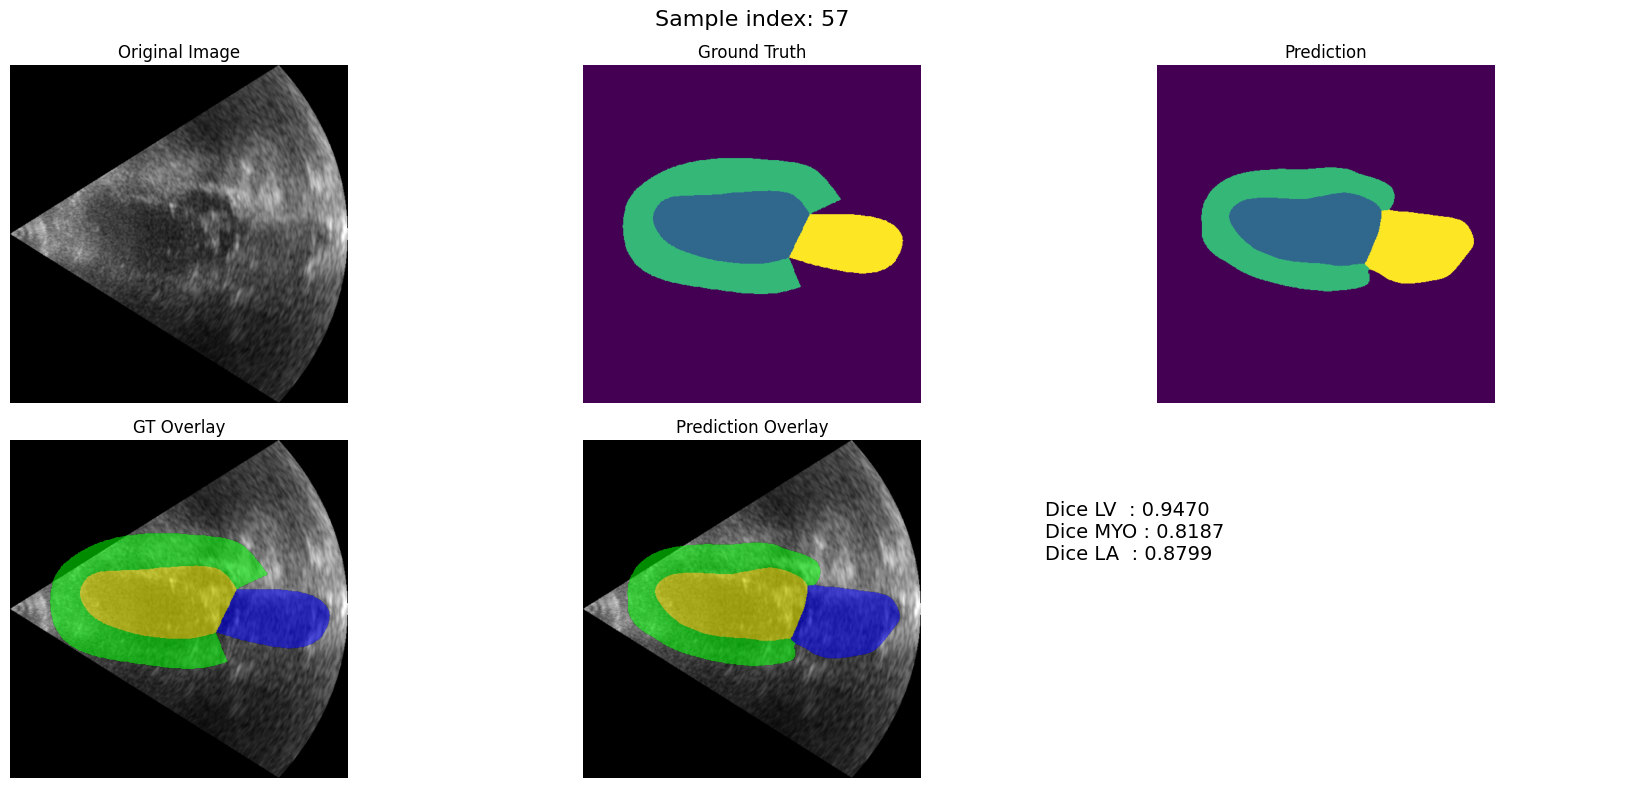

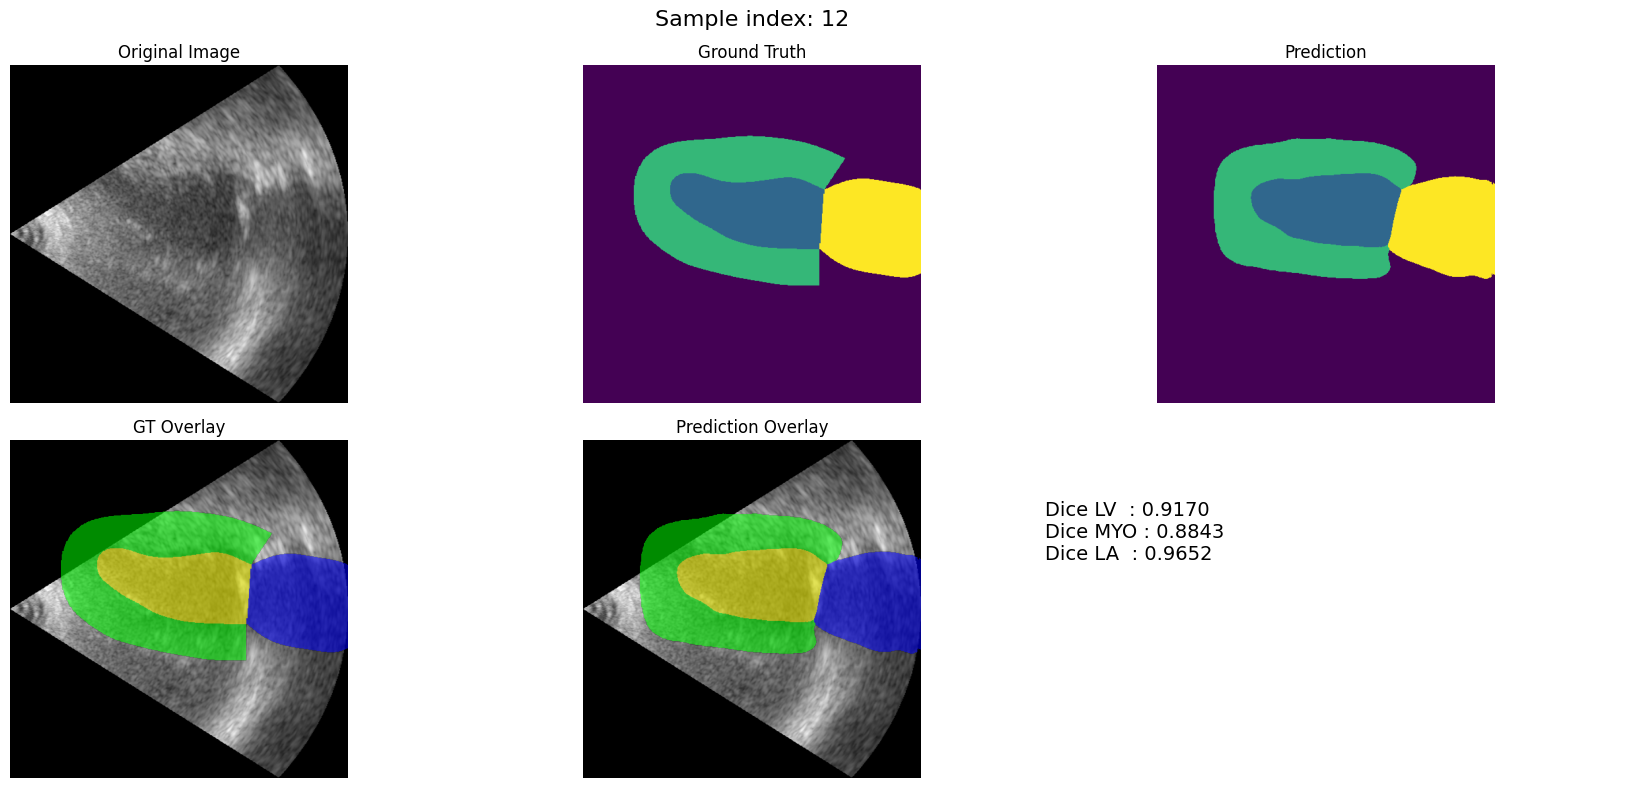

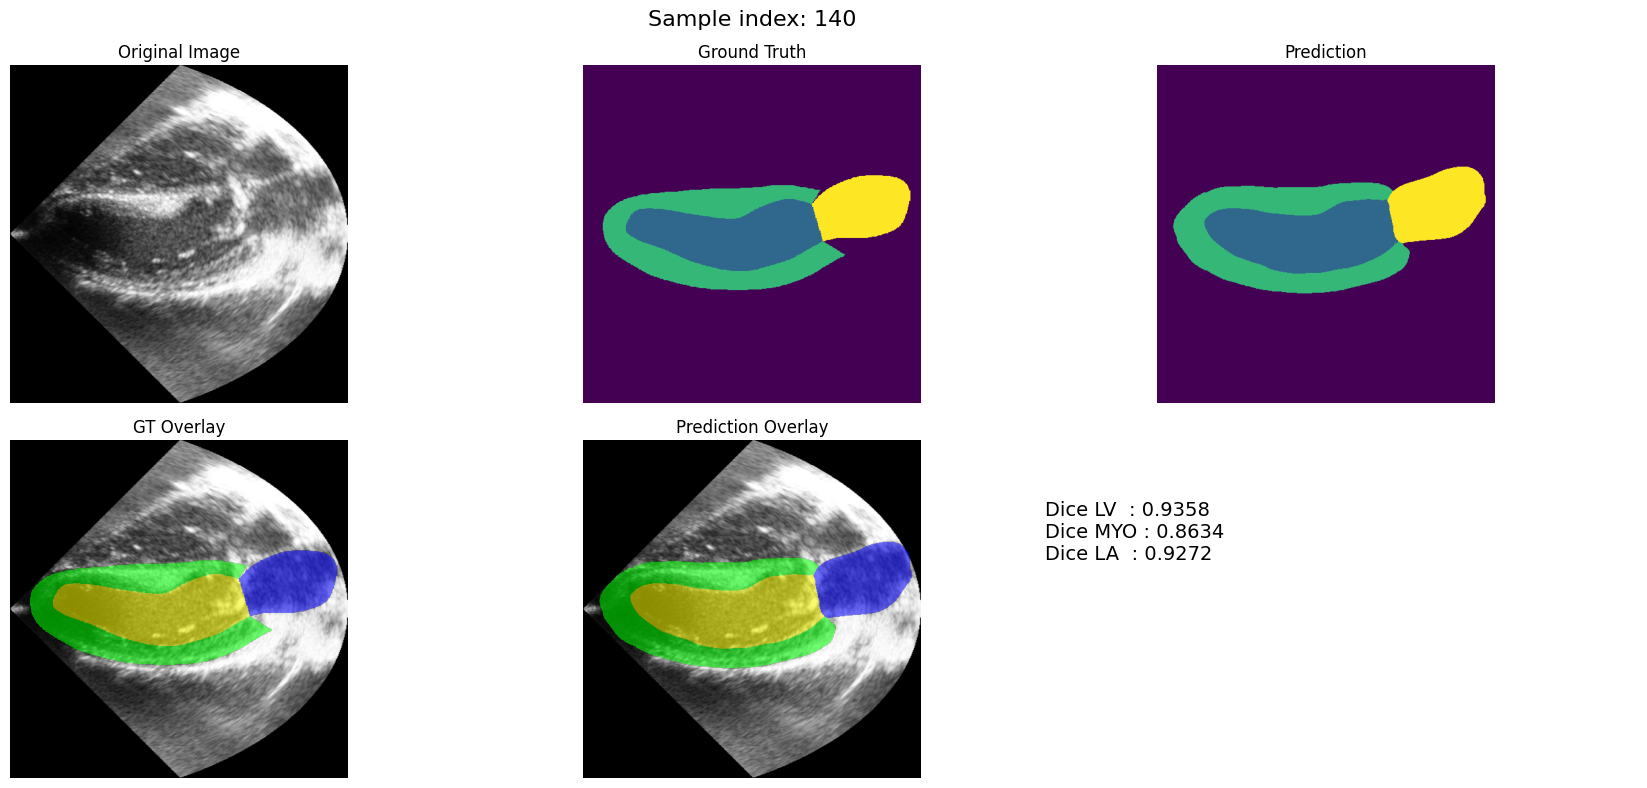


Saving images for report...

Saved 5 examples to: best_model_results_test_set


In [36]:
# ============================================================
# AUTO SELECT BEST MODEL + VISUALISE
# ============================================================

# Sort leaderboard
best_row = leaderboard_df.sort_values(by="fg_dice_mean", ascending=False).iloc[0]

best_name = best_row["Experiment_Name"]
best_score = best_row["fg_dice_mean"]

print("Best Model:", best_name)
print("Best Test Dice Score:", round(best_score, 4))


# Map experiment names to models
model_dict = {
    "Paper1_UNet_weighted_non_focal": m1_wn,
    "Paper2_DeepLabV3_weighted_non_focal": m2_wn,
    "Paper3_UNet_CE+Dice_weighted_non_focal": m3_wn,
    "Paper4_ResUNet_weighted_non_focal": m4_wn,
    "Paper5_UNet_Baseline_weighted_non_focal": m5_wn,
    "AttentionUNet_weighted_non_focal": m6_wn,
    "UNetPP_weighted_non_focal": m7_wn,

    "Paper1_UNet_weighted_focal_dice": m1_wf,
    "Paper2_DeepLabV3_weighted_focal_dice": m2_wf,
    "Paper3_UNet_CE+Dice_weighted_focal_dice": m3_wf,
    "Paper4_ResUNet_weighted_focal_dice": m4_wf,
    "Paper5_UNet_Baseline_weighted_focal_dice": m5_wf,
    "AttentionUNet_weighted_focal_dice": m6_wf,
    "UNetPP_weighted_focal_dice": m7_wf,

    "Paper1_UNet_balanced_non_focal": m1_bn,
    "Paper2_DeepLabV3_balanced_non_focal": m2_bn,
    "Paper3_UNet_CE+Dice_balanced_non_focal": m3_bn,
    "Paper4_ResUNet_balanced_non_focal": m4_bn,
    "Paper5_UNet_Baseline_balanced_non_focal": m5_bn,
    "AttentionUNet_balanced_non_focal": m6_bn,
    "UNetPP_balanced_non_focal": m7_bn,

    "Paper1_UNet_balanced_focal_dice": m1_bf,
    "Paper2_DeepLabV3_balanced_focal_dice": m2_bf,
    "Paper3_UNet_CE+Dice_balanced_focal_dice": m3_bf,
    "Paper4_ResUNet_balanced_focal_dice": m4_bf,
    "Paper5_UNet_Baseline_balanced_focal_dice": m5_bf,
    "AttentionUNet_balanced_focal_dice": m6_bf,
    "UNetPP_balanced_focal_dice": m7_bf,

    "Recommended_UNet_improved_ce_dice": r1,
    "Recommended_AttentionUNet_improved_ce_dice": r2,
    "Recommended_UNetPP_improved_ce_dice": r3,
    "Recommended_DeepLabV3_improved_ce_dice": r4,
    "Recommended_ResUNet_improved_ce_dice": r5,
}

# Get best trained model
best_model = model_dict[best_name]


# ---------------------------
# SHOW RESULTS
# ---------------------------
print("\nShowing visual results from TEST set...\n")

for _ in range(3):
    show_prediction(best_model, test_ds, device=device)


# ---------------------------
# SAVE IMAGES FOR REPORT
# ---------------------------
print("\nSaving images for report...\n")

save_random_examples(
    best_model,
    test_ds,
    n=5,
    save_dir="best_model_results_test_set",
    device=device
)